# 01 - Dataset exploration

This notebook inspects the public Bitext support data before modeling. Cleaning stays conservative because punctuation, negation, phrasing, and spelling variants can be useful to a pretrained tokenizer. The reusable implementation is in `src/eda.py`; figures are saved under `reports/figures/`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import settings
from src.data_loader import load_raw_dataframe, prepare_data


## Raw shape, schema, missing values, and duplicates

In [2]:
raw = load_raw_dataframe()
print('Shape:', raw.shape)
print('Columns:', raw.columns.tolist())
display(raw.isna().sum().rename('missing'))
print('Duplicate rows:', raw.duplicated().sum())
display(raw.head())

Shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


flags          0
instruction    0
category       0
intent         0
response       0
Name: missing, dtype: int64

Duplicate rows: 0


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## Clean data, classes, lengths, and examples

The next cell shows every requested statistic and generates the intent-distribution and ticket-length figures. Compare the largest-to-smallest class ratio with the plot: a ratio near one is balanced, while a large ratio makes macro metrics especially important. The 95th-percentile line is a useful starting point for Transformer truncation length.

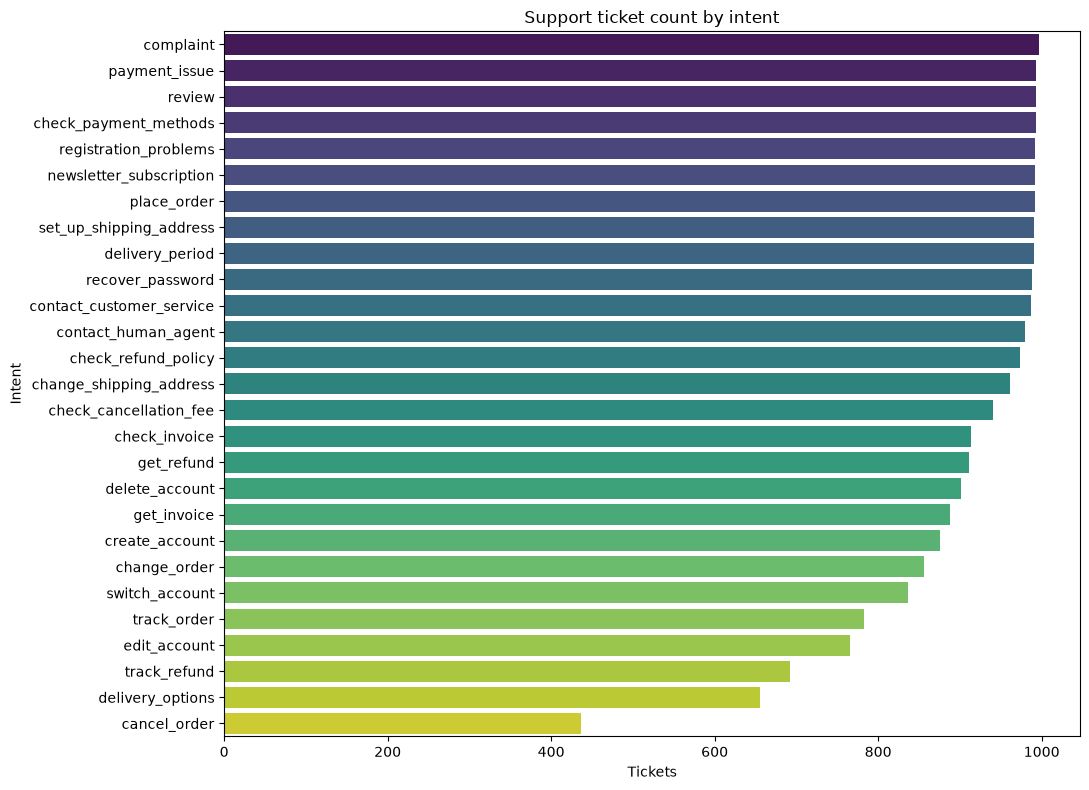

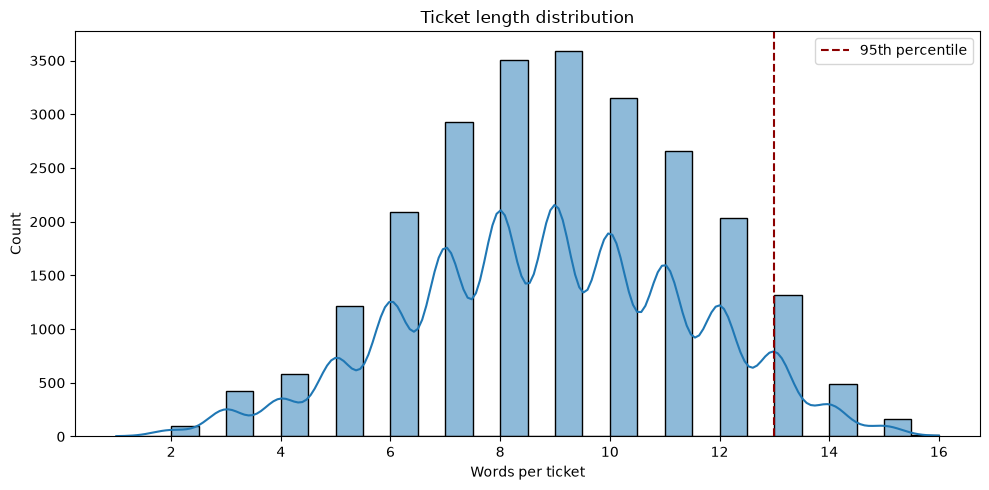

{
  "raw_shape": [
    26872,
    5
  ],
  "raw_columns": [
    "flags",
    "instruction",
    "category",
    "intent",
    "response"
  ],
  "raw_missing_values": {
    "flags": 0,
    "instruction": 0,
    "category": 0,
    "intent": 0,
    "response": 0
  },
  "raw_duplicate_rows": 0,
  "clean_shape": [
    24274,
    2
  ],
  "number_of_intent_classes": 27,
  "average_words": 8.863145752657164,
  "median_words": 9.0,
  "average_characters": 47.03579962099366,
  "shortest_ticket": "register",
  "shortest_ticket_words": 1,
  "longest_ticket": "I do not know what I need to do to change to the {{Account Type}} acount",
  "longest_ticket_words": 16,
  "largest_class_size": 997,
  "smallest_class_size": 436,
  "imbalance_ratio_largest_to_smallest": 2.286697247706422,
  "split_sizes": {
    "train": 16991,
    "validation": 3641,
    "test": 3642
  }
}

One example from each intent:
                  intent                                                      instruction
            ca

In [3]:
from src.eda import run_eda
summary = run_eda()

In [4]:
import pandas as pd
splits = prepare_data()
clean = pd.concat(splits.values(), ignore_index=True)
counts = clean[settings.label_column].value_counts()
display(counts.rename('tickets').to_frame())
display(clean.groupby(settings.label_column, sort=True).first().reset_index())

,tickets
intent,
complaint,997
payment_issue,993
review,993
check_payment_methods,993
registration_problems,992
newsletter_subscription,992
place_order,992
set_up_shipping_address,990
delivery_period,990


,intent,instruction
0,cancel_order,I want assistance canceling purchase {{Order N...
1,change_order,assistance to add a damn article to order {{Or...
2,change_shipping_address,errors updating shipping address
3,check_cancellation_fee,can you help me see the early exit penalties?
4,check_invoice,I want help seeing the invoices from {{Person ...
5,check_payment_methods,can uhelp me check what damn pamyent options a...
6,check_refund_policy,show me in which cases can I ask for refunds
7,complaint,can uhelpp me filing a reclamation against ur ...
8,contact_customer_service,uhave a free of charge number to talk with cus...
9,contact_human_agent,I don't know how to contact an asgent


## Observations to record after execution

1. Note whether missing/duplicate removal materially changes the row count.
2. Name the smallest and largest intents and calculate their ratio.
3. Read examples from semantically close intents and write down ambiguous boundaries.
4. Compare the median, 95th percentile, and maximum length; long outliers alone should not force padding every batch to 512.